In [4]:
import pandas as pd,numpy as np,seaborn as sns,matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
df=pd.read_csv("dataset.csv")
X=df[["size_sqft","area_sqft","rooms"]]
y=df["price"]


Correlation Matrix:
            size_sqft  area_sqft     rooms
size_sqft   1.000000   0.999955  0.974617
area_sqft   0.999955   1.000000  0.976206
rooms       0.974617   0.976206  1.000000


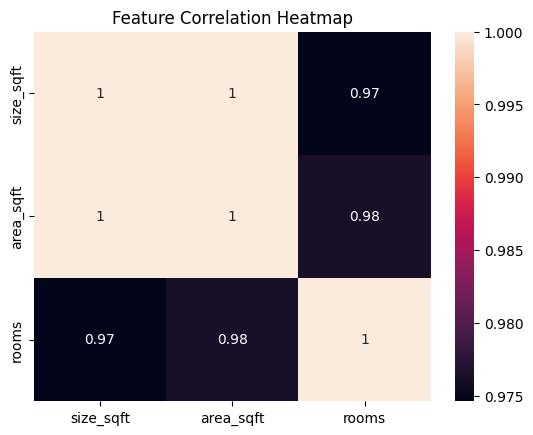

In [6]:
print("Correlation Matrix:\n", X.corr())

sns.heatmap(X.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
def calculate_vif(data):
    vif = pd.DataFrame()
    vif["feature"] = data.columns
    vif["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif

print("\nVIF before removing features:")
print(calculate_vif(X))






VIF before removing features:
     feature           VIF
0  size_sqft  79256.306748
1  area_sqft  81850.920023
2      rooms     75.131808


In [8]:
model = LinearRegression()
model.fit(X, y)

print("\nCoefficients WITH multicollinearity:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")


Coefficients WITH multicollinearity:
size_sqft: 1.3461716937354717
area_sqft: -1.2371229698375585
rooms: 51.03016241299222


In [9]:
X_clean = df[["size_sqft","rooms"]]

print("\nVIF after removing feature:")
print(calculate_vif(X_clean))



VIF after removing feature:
     feature        VIF
0  size_sqft  52.973195
1      rooms  52.973195


In [11]:
# As VIF is Still very high,so we are choosing only size_sqft
x=df[["size_sqft"]]
model.fit(X_clean, y)

print("\nCoefficients AFTER removing multicollinearity:")
for feature, coef in zip(x.columns, model.coef_):
    print(f"{feature}: {coef}")


Coefficients AFTER removing multicollinearity:
size_sqft: 0.15032437442076
